In [256]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import joblib
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from scipy.stats import ttest_ind
from sklearn.compose import ColumnTransformer

In [257]:
dataset = pd.read_csv (r"C:\Users\karan\OneDrive\Desktop\DS_datasets\telco_dataset\telco.csv")
dataset.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [258]:
print(f'Number of rows in dataset', {dataset.shape[0]})
print(f"Number of column in dataset: {dataset.shape[1]}")
print(dataset.columns)


Number of rows in dataset {7043}
Number of column in dataset: 50
Index(['Customer ID', 'Gender', 'Age', 'Under 30', 'Senior Citizen', 'Married',
       'Dependents', 'Number of Dependents', 'Country', 'State', 'City',
       'Zip Code', 'Latitude', 'Longitude', 'Population', 'Quarter',
       'Referred a Friend', 'Number of Referrals', 'Tenure in Months', 'Offer',
       'Phone Service', 'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Satisfaction Score', 'Customer Status', 'Churn Label',
       'Churn Score', 'CLTV', 'Churn Category',

In [259]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [260]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 50 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Under 30                           7043 non-null   object 
 4   Senior Citizen                     7043 non-null   object 
 5   Married                            7043 non-null   object 
 6   Dependents                         7043 non-null   object 
 7   Number of Dependents               7043 non-null   int64  
 8   Country                            7043 non-null   object 
 9   State                              7043 non-null   object 
 10  City                               7043 non-null   object 
 11  Zip Code                           7043 non-null   int64

In [261]:
dataset.describe()

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Population,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Churn Score,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,22139.603294,1.951867,32.386767,22.958954,20.515405,64.761692,2280.381264,1.962182,6.860713,749.099262,3034.379056,3.244924,58.505040,4400.295755
std,16.750352,0.962802,1856.767505,2.468929,2.154425,21152.392837,3.001199,24.542061,15.448113,20.418940,30.090047,2266.220462,7.902614,25.104978,846.660055,2865.204542,1.201657,21.170031,1183.057152
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,11.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.000000,0.000000,0.000000,21.360000,1.000000,5.000000,2003.000000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,2344.000000,0.000000,9.000000,9.210000,3.000000,35.500000,400.150000,0.000000,0.000000,70.545000,605.610000,3.000000,40.000000,3469.000000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,17554.000000,0.000000,29.000000,22.890000,17.000000,70.350000,1394.550000,0.000000,0.000000,401.440000,2108.640000,3.000000,61.000000,4527.000000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,36125.000000,3.000000,55.000000,36.395000,27.000000,89.850000,3786.600000,0.000000,0.000000,1191.100000,4801.145000,4.000000,75.500000,5380.500000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,105285.000000,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000,5.000000,96.000000,6500.000000


In [262]:
dataset.isnull().sum()

Customer ID                             0
Gender                                  0
Age                                     0
Under 30                                0
Senior Citizen                          0
Married                                 0
Dependents                              0
Number of Dependents                    0
Country                                 0
State                                   0
City                                    0
Zip Code                                0
Latitude                                0
Longitude                               0
Population                              0
Quarter                                 0
Referred a Friend                       0
Number of Referrals                     0
Tenure in Months                        0
Offer                                3877
Phone Service                           0
Avg Monthly Long Distance Charges       0
Multiple Lines                          0
Internet Service                  

In [263]:
dataset['Churn Category']=dataset['Churn Category'].fillna('Not Churned')
dataset['Churn Reason']=dataset['Churn Reason'].fillna("Not Churned")
dataset['Internet Type']=dataset['Internet Type'].fillna('No internet')
dataset['Offer']=dataset['Offer'].fillna('No Offer')

In [264]:
dataset.isnull().sum().sum()

np.int64(0)

In [265]:
Q1 =dataset["Total Charges"].quantile(0.25)
Q3 =dataset["Total Charges"].quantile(0.75)

IQR = Q3-Q1
lower = Q1-1.5*IQR
upper = Q3+1.5*IQR

Outliers =dataset[
(dataset["Total Charges"]<lower) |
    (dataset['Total Charges']>upper)
]
print("Number of Outliers :",Outliers.shape[0])

Number of Outliers : 0


In [266]:
churned = dataset[dataset["Churn Label"] == "Yes"]["Monthly Charge"]
not_churned = dataset[dataset["Churn Label"] == "No"]["Monthly Charge"]

t_stat, p_value = ttest_ind(churned, not_churned)
print(p_value)

2.706645606889279e-60


In [267]:
print("Interpretation:")
print("Hypothesis testing shows that Monthly Charge has a statistically significant impact on customer churn (p < 0.05)")
print("Churned customers pay higher monthly charges on average, indicating price sensitivity")

print("Business Insight:")
print("Customers with higher monthly bills are more likely to churn")
print("This suggests that pricing plays a key role in customer retention")
print("Monthly Charge has a strong impact on customer churn")


Interpretation:
Hypothesis testing shows that Monthly Charge has a statistically significant impact on customer churn (p < 0.05)
Churned customers pay higher monthly charges on average, indicating price sensitivity
Business Insight:
Customers with higher monthly bills are more likely to churn
This suggests that pricing plays a key role in customer retention
Monthly Charge has a strong impact on customer churn


In [268]:
churned = dataset[dataset["Churn Label"] == "Yes"]["Tenure in Months"]
not_churned = dataset[dataset["Churn Label"] == "No"]["Tenure in Months"]

t_stat, p_value = ttest_ind(churned, not_churned)
print(p_value)


1.3292218158997983e-205


In [269]:
print("Interpretation: Tenure in Months vs Churn")
print("Hypothesis testing shows that Tenure in Months has a statistically significant impact on customer churn (p < 0.05).")  
print("There is a meaningful difference in tenure between churned and non-churned customers")

Interpretation: Tenure in Months vs Churn
Hypothesis testing shows that Tenure in Months has a statistically significant impact on customer churn (p < 0.05).
There is a meaningful difference in tenure between churned and non-churned customers


In [270]:
dataset.groupby("Churn Label")["Tenure in Months"].mean()


Churn Label
No     37.591225
Yes    17.979133
Name: Tenure in Months, dtype: float64

In [271]:
print('Business insight :')
print('Customers with shorter tenure are significantly more likely to churn')
print("This suggests that churn risk is highest during the early months of the customer lifecycle")

Business insight :
Customers with shorter tenure are significantly more likely to churn
This suggests that churn risk is highest during the early months of the customer lifecycle


Text(0.5, 1.0, 'Churn Distribution')

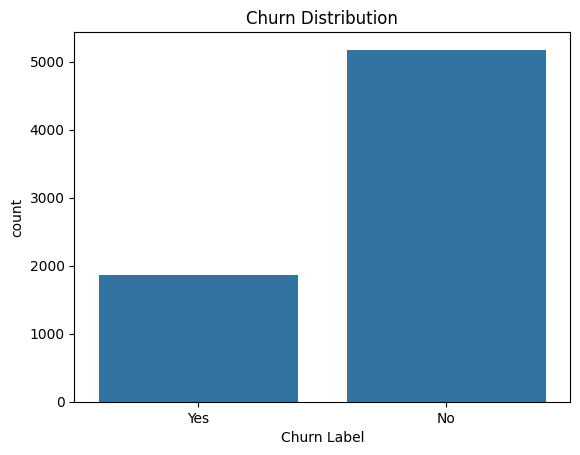

In [272]:
sns.countplot(x="Churn Label", data=dataset)
plt.title("Churn Distribution")

Text(0.5, 1.0, 'Numerical Charge with churn')

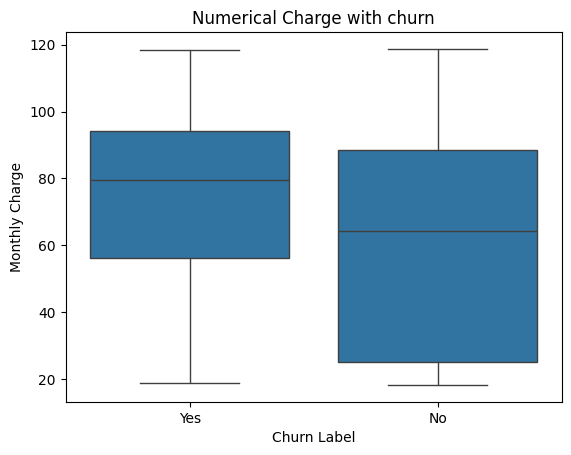

In [273]:
sns.boxplot(x="Churn Label", y="Monthly Charge", data=dataset)
plt.title("Numerical Charge with churn")

Text(0.5, 1.0, 'Churn Customers with Tenure')

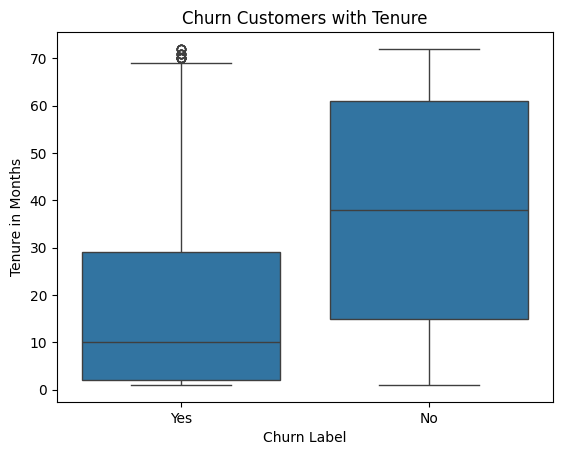

In [274]:
sns.boxplot(x="Churn Label", y="Tenure in Months", data=dataset)
plt.title('Churn Customers with Tenure')

Text(0.5, 1.0, 'Total Revenue of Churn')

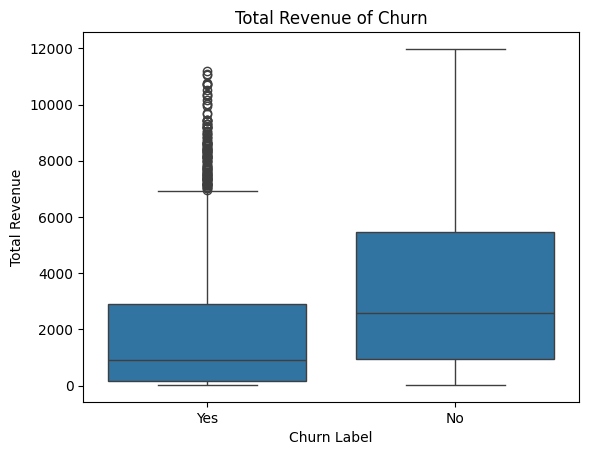

In [275]:
sns.boxplot(x="Churn Label", y="Total Revenue", data=dataset)
plt.title("Total Revenue of Churn")

Text(0.5, 1.0, 'Payment Method VS Churn')

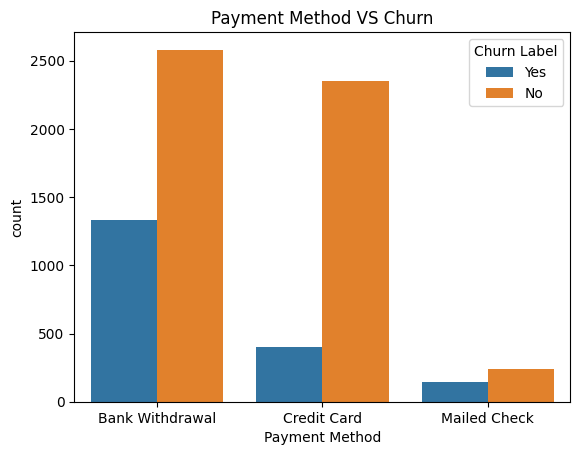

In [276]:
sns.countplot(x="Payment Method", hue="Churn Label", data=dataset)
plt.title("Payment Method VS Churn")

Text(0.5, 1.0, 'Internet Type VS Churn')

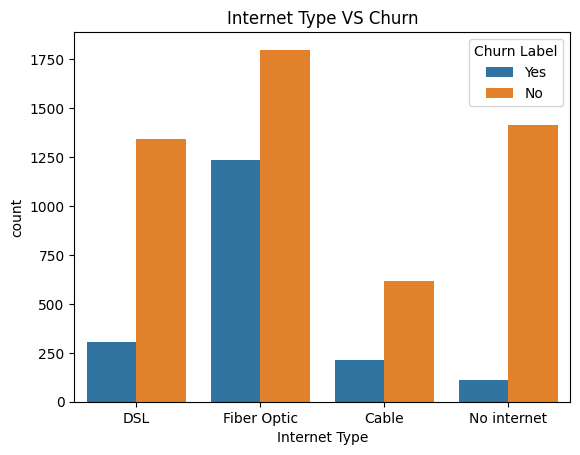

In [277]:
sns.countplot(x="Internet Type", hue="Churn Label", data=dataset)
plt.title("Internet Type VS Churn")

Text(0.5, 1.0, 'Contract Vs Churn')

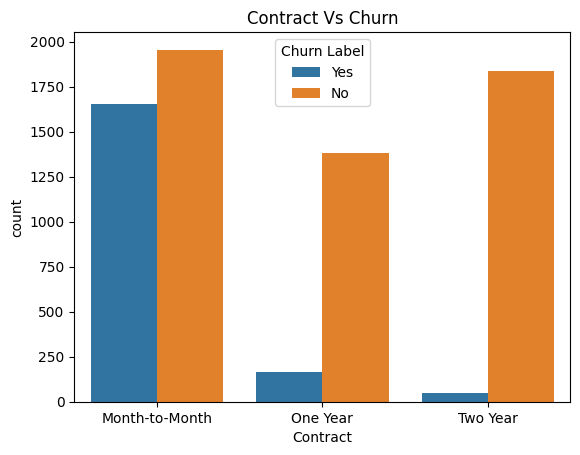

In [278]:
sns.countplot(x="Contract", hue="Churn Label", data=dataset)
plt.title("Contract Vs Churn")

In [279]:
print("From EDA and hypothesis testing, we found that Monthly Charge, Tenure in Months, Contract Type, and Internet Type strongly affect customer churn. These features will be used to build the churn prediction model.")

From EDA and hypothesis testing, we found that Monthly Charge, Tenure in Months, Contract Type, and Internet Type strongly affect customer churn. These features will be used to build the churn prediction model.


In [280]:
#remove unused Columns
X =dataset.drop(["Customer ID",
    "Churn Label",
    "Customer Status",
    "Churn Category",
    "Churn Reason"],axis=1)
y =dataset["Churn Label"]

In [281]:
#feature Engeenering
dataset["TotalSpend"] = (
    dataset["Total Revenue"] +
    dataset["Total Extra Data Charges"] +
    dataset["Total Long Distance Charges"]
)

dataset["AgeGroup"] = pd.cut(
    dataset["Age"],
    bins=[0, 30, 60, 100],
    labels=["Young", "Adult", "Senior"]
)
dataset["HasDependents"] = (dataset["Dependents"] == "Yes").astype(int)


In [282]:
#label Encoding on Binary Column
le = LabelEncoder()
data_columns = [
    "Gender", "Married", "Dependents",
    "Under 30", "Senior Citizen"
]

encoded = le.fit_transform(data_columns)
print(encoded)


[1 2 0 4 3]


In [283]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)


In [284]:
#ML Pipeline
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
    ]
)

model = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers

In [285]:
y_pred =model.predict(X_test)

In [286]:
print("Prediction",y_pred[:10])

Prediction ['Yes' 'No' 'No' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'No' 'Yes']


In [287]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[997  12]
 [ 18 382]]
              precision    recall  f1-score   support

          No       0.98      0.99      0.99      1009
         Yes       0.97      0.95      0.96       400

    accuracy                           0.98      1409
   macro avg       0.98      0.97      0.97      1409
weighted avg       0.98      0.98      0.98      1409



In [288]:
print("Total test customers:", len(X_test))
print("Predicted churn:", (y_pred == "Yes").sum())
print("Predicted non-churn:", (y_pred == "No").sum())


Total test customers: 1409
Predicted churn: 394
Predicted non-churn: 1015


In [289]:
joblib.dump(model,"Customer_Churn_pipeline.pkl")
print("Model Saves Successfully")

Model Saves Successfully


In [290]:
lodead_model =joblib.load("Customer_Churn_pipeline.pkl")

In [291]:
new_predictions = lodead_model.predict(X_test)
print(new_predictions[0:])

['Yes' 'No' 'No' ... 'Yes' 'No' 'No']
